# 01 - Dataset Exploration

## Goal

This notebook validates the complete data loading pipeline before any modeling.

Objectives:
- Understand the BioHub dataset structure
- Explore microscopy volumes
- Explore GEFF annotations
- Validate ZarrReader
- Validate GEFFReader
- Validate BioHubDataset
- Verify annotation alignment
- Record initial observations


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import zarr

from src.data.zarr_reader import ZarrReader
from src.data.geff_reader import GEFFReader
from src.data.dataloader import BioHubDataset

## 1. Load Sample

In [2]:
sample_name = "6bba_786893ac"

volume = ZarrReader(Path(f"../data/raw/train/{sample_name}.zarr"))
annotations = GEFFReader(Path(f"../data/raw/train/{sample_name}.geff"))

volume

ZarrReader(path='6bba_786893ac.zarr', shape=(100, 64, 256, 256), dtype=uint16)

## 2. Inspect Volume Metadata

In [3]:
print("Shape:", volume.shape)
print("Dtype:", volume.dtype)
print("Frame 0 Shape:", volume[0].shape)

Shape: (100, 64, 256, 256)
Dtype: uint16
Frame 0 Shape: (64, 256, 256)


## 3. Visualize Single Z Slice

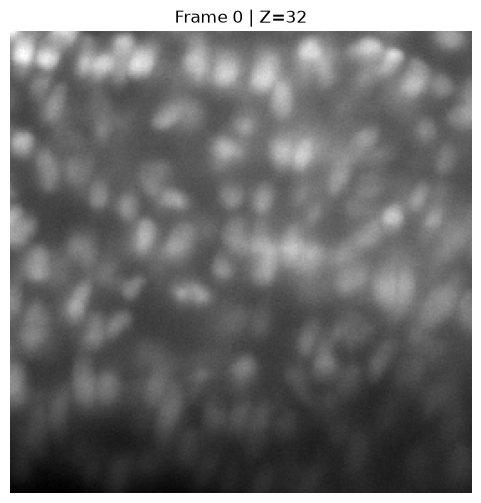

In [4]:
frame = volume[0]
z = frame.shape[0] // 2

plt.figure(figsize=(6,6))
plt.imshow(frame[z], cmap="gray")
plt.title(f"Frame 0 | Z={z}")
plt.axis("off");

## 4. Pixel Intensity Distribution

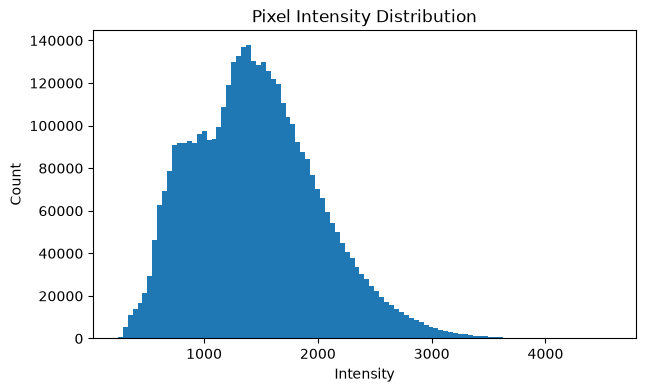

In [5]:
plt.figure(figsize=(7,4))
plt.hist(frame.flatten(), bins=100)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Count");

## 5. Maximum Intensity Projection

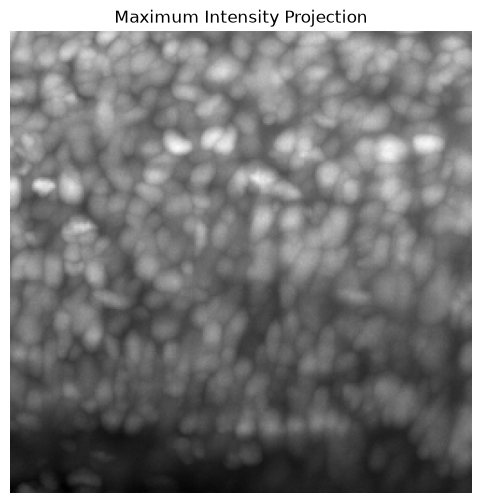

In [6]:
mip = frame.max(axis=0)

plt.figure(figsize=(6,6))
plt.imshow(mip, cmap="gray")
plt.title("Maximum Intensity Projection")
plt.axis("off");

## 6. Temporal Visualization

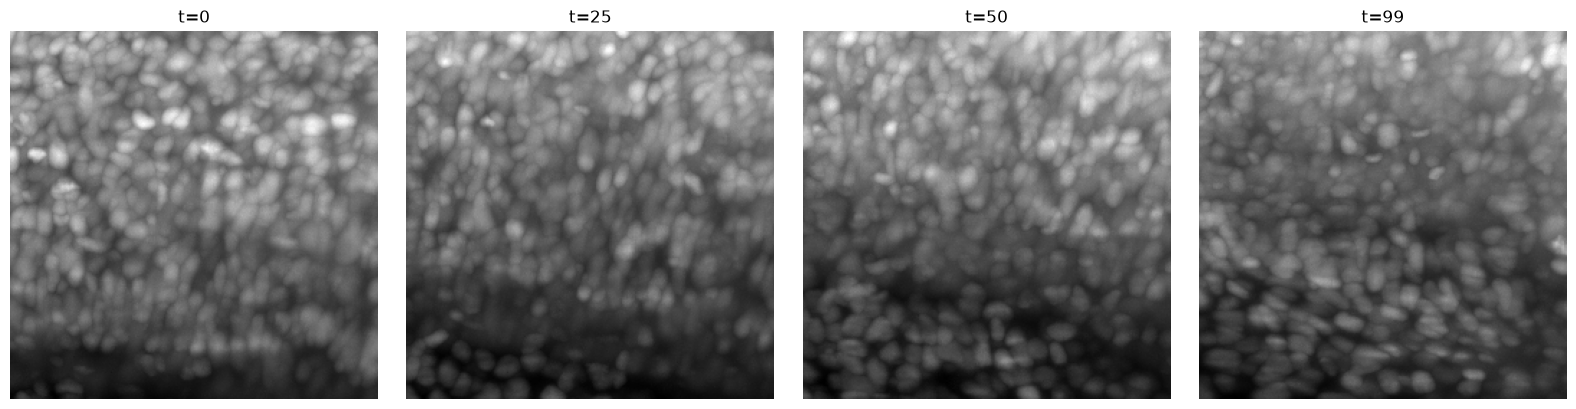

In [7]:
times = [0,25,50,99]

fig, axes = plt.subplots(1,4, figsize=(16,4))

for ax,t in zip(axes,times):
    mip = volume[t].max(axis=0)
    ax.imshow(mip,cmap="gray")
    ax.set_title(f"t={t}")
    ax.axis("off")

plt.tight_layout()

## 7. Explore GEFF Structure

In [8]:
root = zarr.open_group(Path(f"../data/raw/train/{sample_name}.geff"), mode="r")
root.tree()

/Users/axstormx/Downloads/kaggle-competition/biohub-cell-tracking/.venv/lib/python3.12/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at .DS_Store is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


/
├── edges
│   ├── ids (1395, 2) uint64
│   └── props
└── nodes
    ├── ids (1465,) uint64
    └── props
        ├── t
        │   └── values (1465,) int64
        ├── x
        │   └── values (1465,) int64
        ├── y
        │   └── values (1465,) int64
        └── z
            └── values (1465,) int64

## 8. Validate GEFFReader

In [9]:
reader = GEFFReader(Path(f"../data/raw/train/{sample_name}.geff"))

print(reader)
print("Nodes:", len(reader.nodes))
print("Edges:", len(reader.edges))

reader.nodes[:5]

GEFFReader(path='6bba_786893ac.geff', nodes=1465, edges=1395)
Nodes: 1465
Edges: 1395


(Node(id=1000011, t=0, z=31, y=119, x=40, confidence=1.0),
 Node(id=1000013, t=0, z=24, y=31, x=224, confidence=1.0),
 Node(id=1000014, t=0, z=26, y=128, x=140, confidence=1.0),
 Node(id=1000017, t=0, z=29, y=20, x=62, confidence=1.0),
 Node(id=1000018, t=0, z=30, y=26, x=197, confidence=1.0))

## 9. Validate BioHubDataset

In [10]:
dataset = BioHubDataset("../data/raw/train")

sample = dataset[sample_name]

print(sample.name)
print(sample.volume)
print("Nodes:", len(sample.nodes))
print("Edges:", len(sample.edges) )

6bba_786893ac
<Array file://../data/raw/train/6bba_786893ac.zarr/0 shape=(100, 64, 256, 256) dtype=uint16>
Nodes: 1465
Edges: 1395


## 10. Overlay Ground Truth

Frame nodes: 18
Nodes on z=31: 1


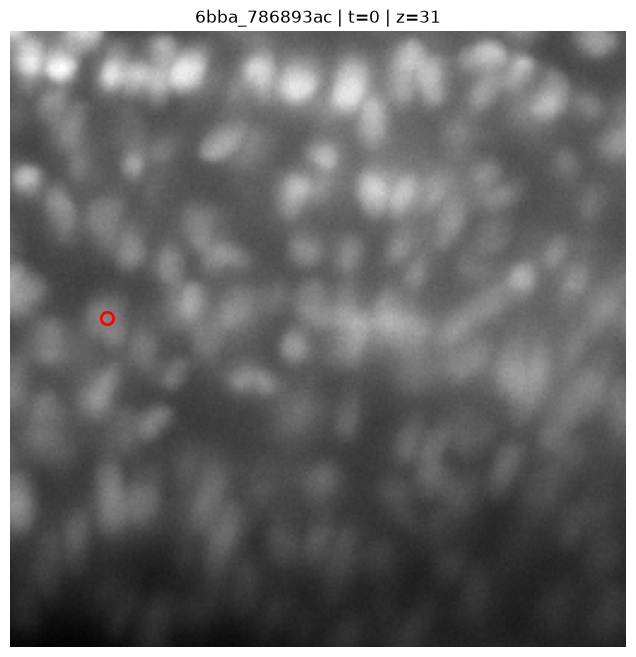

In [11]:
t = 0
z = 31

frame = sample.volume[t]

frame_nodes = [n for n in sample.nodes if n.t == t]
nodes = [n for n in frame_nodes if n.z == z]

plt.figure(figsize=(8,8))
plt.imshow(frame[z], cmap="gray")
plt.scatter(
    [n.x for n in nodes],
    [n.y for n in nodes],
    s=80,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
)

plt.title(f"{sample.name} | t={t} | z={z}")
plt.axis("off")

print(f"Frame nodes: {len(frame_nodes)}")
print(f"Nodes on z={z}: {len(nodes)}")

## 11. Initial Observations

### Findings

- Successfully loaded Zarr microscopy volumes.
- Successfully parsed GEFF tracking annotations.
- Validated `ZarrReader`, `GEFFReader`, and `BioHubDataset`.
- Ground-truth centroids align correctly with fluorescent cells.
- Coordinate system `(x, y, z)` appears correct.
- Dataset contains sparse annotations.
- Data loading layer is now considered validated.

### Next Steps

- Dataset statistics
- Movement statistics
- Track statistics
- Baseline detector
- Baseline tracker
